In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("datasets/cleaned_crime_nbh_2024.csv")

### Shape

In [16]:
df.shape

(14494, 124)

### Uniqueness of Index column

In [ ]:
df["gwb_code_10"].isna().sum(), df["gwb_code_10"].duplicated().sum()

(0, 0)

### Column types overview

In [19]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in df.columns if c not in num_cols]

print("Number of numerical columns:", len(num_cols))
print("Number of categorical columns:", len(cat_cols))
print("Columns considered categorical:", cat_cols[:20])


Number of numerical columns: 121
Number of categorical columns: 3
Columns considered categorical: ['gwb_code_10', 'regio', 'gm_naam']


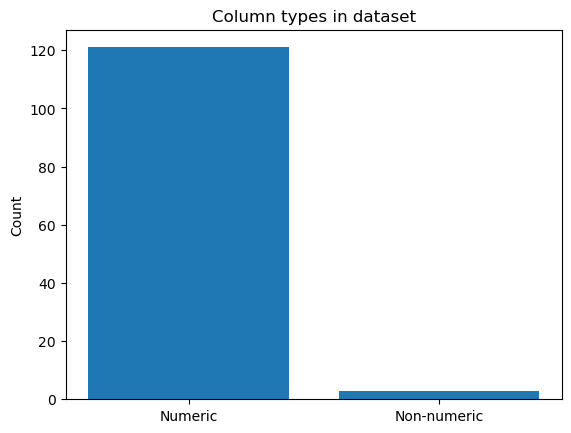

In [21]:
plt.figure()
plt.bar(["Numeric", "Non-numeric"], [len(num_cols), len(cat_cols)])
plt.title("Column types in dataset")
plt.ylabel("Count")
plt.show()


## Target Variable

In [22]:
df["GeregistreerdeMisdrijven_1"].describe()

count    14494.000000
mean        54.725611
std        121.275987
min          0.000000
25%          8.000000
50%         22.000000
75%         57.000000
max       3714.000000
Name: GeregistreerdeMisdrijven_1, dtype: float64

In [ ]:
# Count columns by missingness buckets
n_100 = (miss >= 0.999).sum()
n_20_99 = ((miss >= 0.20) & (miss < 0.999)).sum()
n_10_19 = ((miss >= 0.10) & (miss < 0.20)).sum()
n_1_9 = ((miss >= 0.01) & (miss < 0.10)).sum()
n_0 = (miss < 0.01).sum()

print("100% missing:        ", n_100)
print("20–99% missing:       ", n_20_99)
print("10–19% missing:      ", n_10_19)
print("1–9% missing:        ", n_1_9)
print("No missing (<1%):    ", n_0)
print("Total columns:       ", n_100 + n_20_99 + n_10_19 + n_1_9 + n_0)

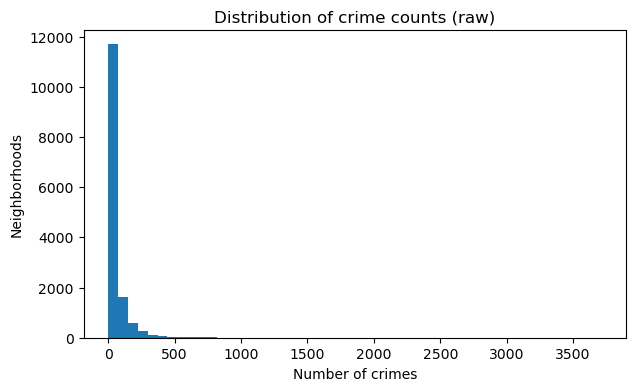

In [31]:
plt.figure(figsize=(7,4))
plt.hist(df["GeregistreerdeMisdrijven_1"], bins=50)
plt.title("Distribution of crime counts (raw)")
plt.xlabel("Number of crimes")
plt.ylabel("Neighborhoods")
plt.show()


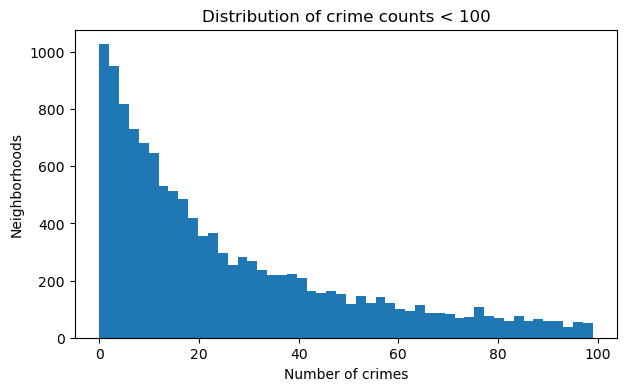

In [77]:
plt.figure(figsize=(7,4))
plt.hist(df[df["GeregistreerdeMisdrijven_1"] < 100]["GeregistreerdeMisdrijven_1"], bins=50)
plt.title("Distribution of crime counts < 100")
plt.xlabel("Number of crimes")
plt.ylabel("Neighborhoods")
plt.show()


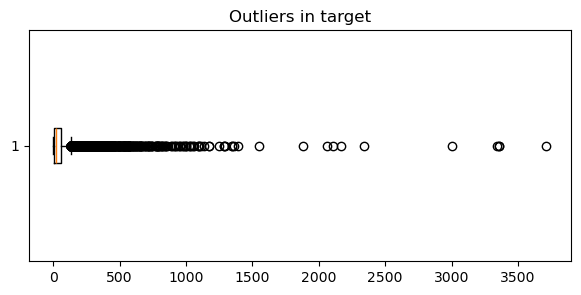

In [33]:
plt.figure(figsize=(7,3))
plt.boxplot(df["GeregistreerdeMisdrijven_1"], vert=False)
plt.title("Outliers in target")
plt.show()

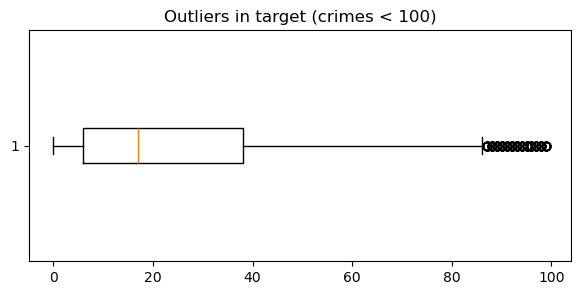

In [99]:
plt.figure(figsize=(7,3))
plt.boxplot(df[df["GeregistreerdeMisdrijven_1"] < 100]["GeregistreerdeMisdrijven_1"], vert=False)
plt.title("Outliers in target (crimes < 100)")
plt.show()

## Missing Data

In [46]:
miss = df.isna().mean().sort_values(ascending=False)
miss.head(30)

p_hh_osm       1.000000
p_arb_wn       1.000000
m_hh_ver       1.000000
p_wmo_t        1.000000
p_hh_120       1.000000
p_jz_tn        1.000000
a_jz_tn        1.000000
a_opl_bvm      1.000000
a_opl_hvm      1.000000
p_hh_110       1.000000
a_opl_hw       1.000000
a_arb_wz       1.000000
a_wmo_t        1.000000
p_arb_pp       1.000000
p_arb_wnv      1.000000
g_ink_pi       1.000000
p_hh_lkk       1.000000
p_hh_hi        1.000000
p_hh_li        1.000000
g_hh_sti       1.000000
p_ink_hi       1.000000
p_ink_li       1.000000
a_lp_pub       1.000000
g_ink_po       1.000000
a_inkont       1.000000
p_arb_zs       1.000000
p_arb_wnf      1.000000
p_stadsv       0.925003
p_won_m_ag     0.300400
p_won_z_ag     0.300400
dtype: float64

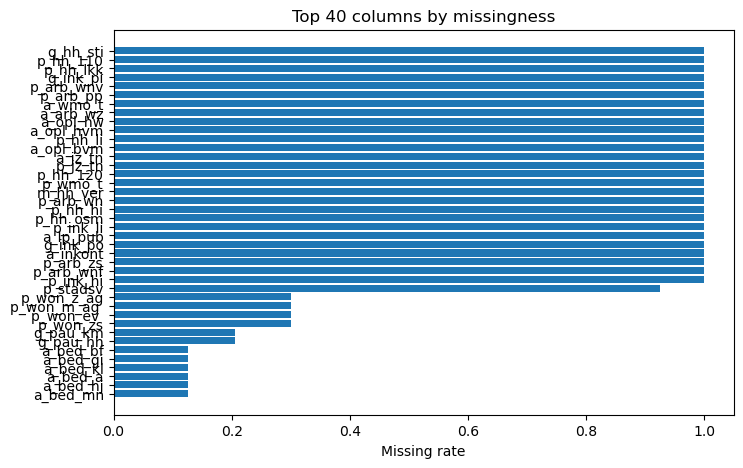

In [50]:
top = miss.head(40).sort_values()

plt.figure(figsize=(8,5))
plt.barh(top.index, top.values)
plt.title("Top 40 columns by missingness")
plt.xlabel("Missing rate")
plt.show()


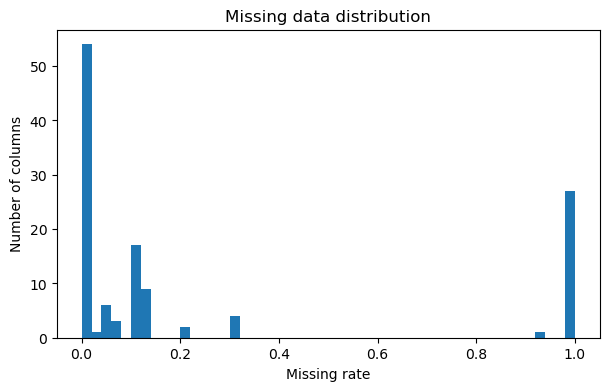

In [70]:
plt.figure(figsize=(7,4))
plt.hist(miss, bins=50)
plt.title("Missing data distribution")
plt.xlabel("Missing rate")
plt.ylabel("Number of columns")
plt.show()

In [71]:
total = len(miss)

def show(label, condition):
    count = miss[condition].count()
    perc = round(count / total * 100, 2)
    print(f"{label}: {count} ({perc}%)")

show("100% missing", miss >= 0.999)
show("50-99% missing", (miss >= 0.5) & (miss < 0.999))
show("20-49% missing", (miss >= 0.2) & (miss < 0.5))
show("10-19% missing", (miss >= 0.1) & (miss < 0.2))
show("1-9% missing", (miss >= 0.01) & (miss < 0.1))
show("Nothing missing", miss < 0.01)

100% missing: 27 (21.77%)
50-99% missing: 1 (0.81%)
20-49% missing: 6 (4.84%)
10-19% missing: 26 (20.97%)
1-9% missing: 10 (8.06%)
Nothing missing: 54 (43.55%)


## Population column

In [83]:
pop_col = df["a_inw"]

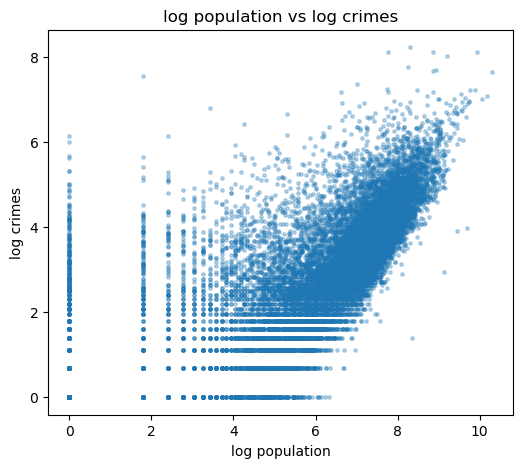

In [89]:
x = pop_col
y = df["GeregistreerdeMisdrijven_1"]

plt.figure(figsize=(6,5))
plt.scatter(np.log1p(x), np.log1p(y), s=6, alpha=0.3)
plt.title("log population vs log crimes")
plt.xlabel("log population")
plt.ylabel("log crimes")
plt.show()


## Feature Behavior

### Skewness

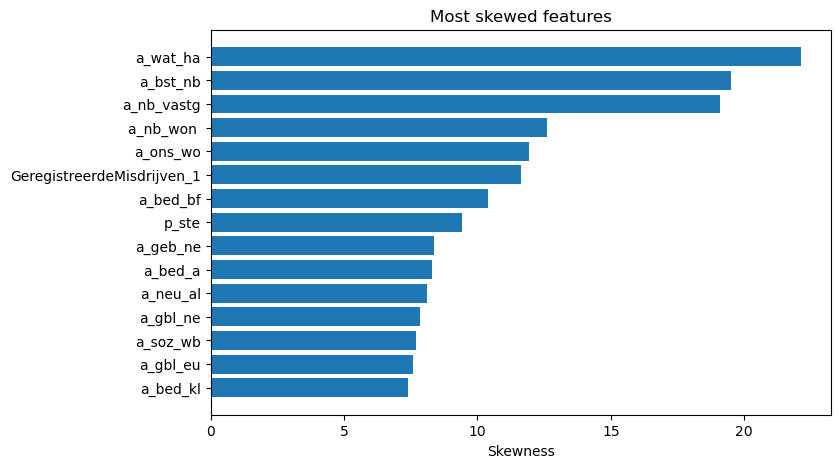

In [91]:
top = skew.head(15).sort_values()

plt.figure(figsize=(8,5))
plt.barh(top.index, top.values)
plt.title("Most skewed features")
plt.xlabel("Skewness")
plt.show()


### Correlation with target

In [92]:
corr = df[num_cols].corrwith(df["GeregistreerdeMisdrijven_1"]).sort_values(key=lambda s: s.abs(), ascending=False)
corr.head(15)

GeregistreerdeMisdrijven_1    1.000000
a_bed_gi                      0.750887
a_bedv                        0.730882
a_1p_hh                       0.727196
a_bed_ru                      0.701376
a_bed_hj                      0.670796
a_25_44                       0.670075
a_ongeh                       0.656121
a_hh                          0.656103
a_eur_al                      0.652701
a_gbl_eu                      0.646120
a_bed_mn                      0.645086
a_gbl_ne                      0.637253
a_15_24                       0.632274
a_woning                      0.631723
dtype: float64

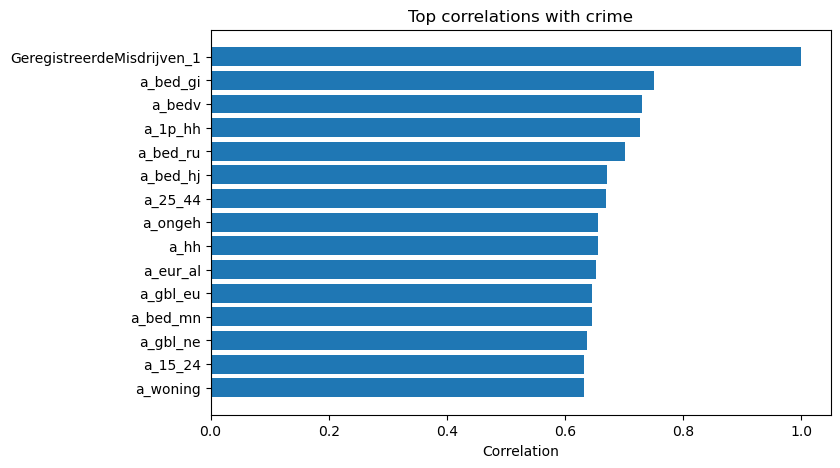

In [93]:
top = corr.head(15).sort_values()

plt.figure(figsize=(8,5))
plt.barh(top.index, top.values)
plt.title("Top correlations with crime")
plt.xlabel("Correlation")
plt.show()


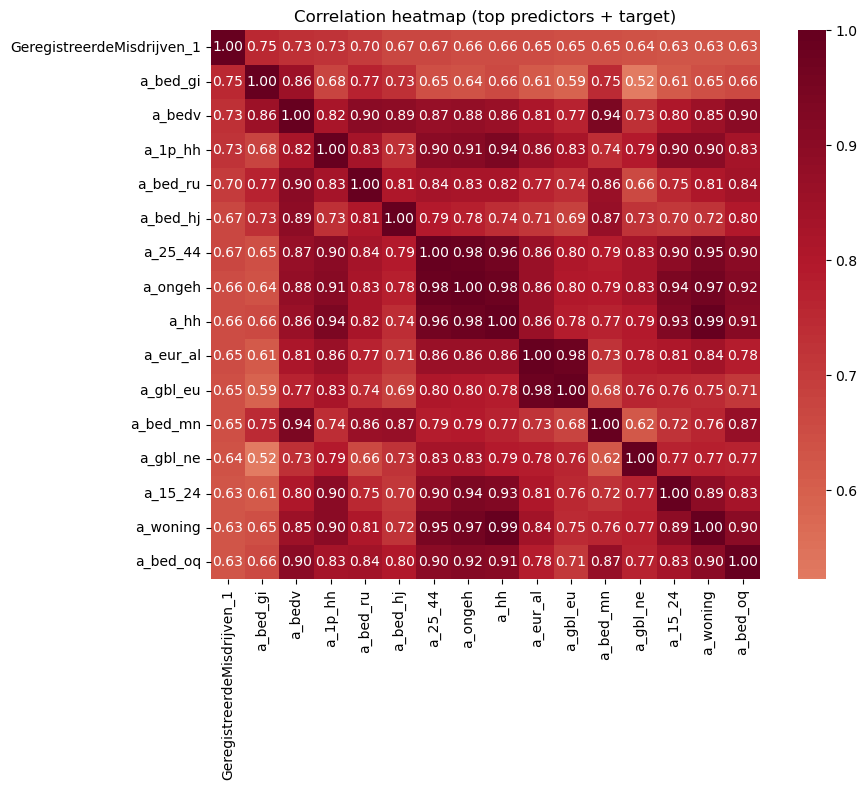

In [94]:
# Correlation heatmap: top 15 predictors + target (subset for readability)
import seaborn as sns
top_vars = corr.head(16).index.tolist()  # top 15 + target
heatmap_data = df[top_vars].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap="RdBu_r", center=0, square=True)
plt.title("Correlation heatmap (top predictors + target)")
plt.tight_layout()
plt.show()